# Core Factorial: Selective Interference Effect

> Simulate the interference × retrieval mode factorial to demonstrate graded vulnerability.

The selective interference effect predicts that a visuospatial task after a
film or reminder impairs involuntary recall more than voluntary recall, while
recognition is completely spared.

This notebook sweeps interference MCF binding strength under three retrieval
modes — involuntary (no retrieval control), voluntary (start-drift +
sharpened competition), and recognition (item-to-context pathway, immune by
architecture) — to show that the gradient emerges from a single memory
system operating at different control settings.

All simulations use `shared_support=0.0` so that retrieval depends entirely
on context-dependent learned associations.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from jax import random
import os

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.selective_interference import (
    Paradigm,
    add_filler_boundary,
    compute_n_presented,
    film_recalled_stats,
    light_to_dark_colors,
    load_or_fit_params,
    make_factory,
    make_is_emotional,
    plot_interference_spc,
    plot_summary_dv,
    prepare_sweep,
    run_sweep,
    standard_remap,
)

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
N_BREAK_MAX = 32
N_INTERFERENCE_MAX = 32
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100

# --- interference sweep ---
MCF_VALUES = [0.0, 0.33, 0.67, 1.0, 1.33, 1.67, 2.0, 2.33, 2.67, 3.0]

# --- retrieval modes ---
# Involuntary: no retrieval control (context stays post-interference)
INVOLUNTARY = {"start_drift_scale": 0.01, "tau_scale": 1.0}
# Voluntary: strong reinstatement + sharpened competition
VOLUNTARY = {"start_drift_scale": 2.0, "tau_scale": 2.0}

# --- encoding scales (held fixed) ---
ENCODING_SCALES = {"interference_drift_scale": 0.5}

# --- pre-cache scales ---
PRE_CACHE_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 4.0,
    "reminder_drift_scale": 0.3,
}

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 3
RUN_TAG = "fixed_term_best_of_3"
REDO_FITS = False
PARAM_SCALES = {"stop_probability_scale": 0.4, "shared_support": 0.0}
FIT_DIR = "projects/selective_interference/simulations/fits"
FIGURE_DIR = "projects/selective_interference/simulations/figures"
FIGURE_STR = "core_factorial"

In [3]:
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_break_max=N_BREAK_MAX,
    n_interference_max=N_INTERFERENCE_MAX,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)

project_root = Path(find_project_root())
fit_path = project_root / FIT_DIR / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)
is_emotional = make_is_emotional(paradigm, False, False)
factory = make_factory(is_emotional=is_emotional)
rng = random.PRNGKey(SEED)

params, n_subjects = load_or_fit_params(
    fit_path,
    param_scales=PARAM_SCALES,
    data=data,
    trial_mask=trial_mask,
    model_factory=factory,
    redo_fits=REDO_FITS,
    best_of=BEST_OF,
)

prep = prepare_sweep(
    params, paradigm, factory,
    cache_after="reminder", tier="standard",
    **PRE_CACHE_SCALES,
)
print(f"{n_subjects} subjects, shared_support=0")

Loaded fits from /Users/jordangunn/jaxcmr/projects/selective_interference/simulations/fits/HealeyKahana2014_WeirdCMRPosStop_fixed_term_best_of_3.json
  Scaled stop_probability_scale by 0.4
  Scaled shared_support by 0.0


126 subjects, shared_support=0


In [4]:
mcf_values = np.array(MCF_VALUES)

# --- Involuntary: no retrieval control ---
recalls_inv, rng = run_sweep(
    prep, rng,
    interference_mcf_scale=mcf_values,
    **ENCODING_SCALES,
    **INVOLUNTARY,
)

# --- Voluntary: strong retrieval control ---
recalls_vol, rng = run_sweep(
    prep, rng,
    interference_mcf_scale=mcf_values,
    **ENCODING_SCALES,
    **VOLUNTARY,
)

# --- Compute stats ---
def _stats(recalls_4d):
    means, ci_los, ci_his = [], [], []
    for i in range(recalls_4d.shape[0]):
        recalls = recalls_4d[i].reshape(-1, recalls_4d.shape[-1])
        recalls = standard_remap(recalls, paradigm)
        m, lo, hi = film_recalled_stats(recalls, paradigm, n_subjects)
        means.append(m)
        ci_los.append(lo)
        ci_his.append(hi)
    return means, ci_los, ci_his

inv_means, inv_lo, inv_hi = _stats(recalls_inv)
vol_means, vol_lo, vol_hi = _stats(recalls_vol)

print(f"Involuntary: mcf=0 → {inv_means[0]:.1f}, mcf=3 → {inv_means[-1]:.1f}, effect={inv_means[0]-inv_means[-1]:+.1f}")
print(f"Voluntary:   mcf=0 → {vol_means[0]:.1f}, mcf=3 → {vol_means[-1]:.1f}, effect={vol_means[0]-vol_means[-1]:+.1f}")

Involuntary: mcf=0 → 0.1, mcf=3 → 0.0, effect=+0.1
Voluntary:   mcf=0 → 2.0, mcf=3 → 0.8, effect=+1.2


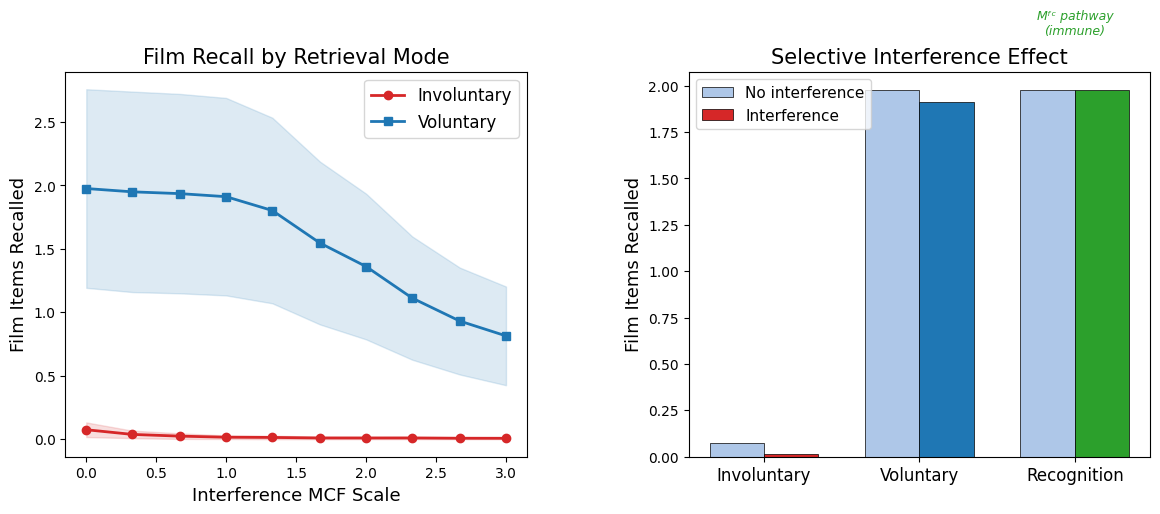

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"wspace": 0.35})

# --- Left: dose-response curves ---
ax = axes[0]
x = mcf_values.tolist()

ax.plot(x, inv_means, "o-", color="#d62728", linewidth=2, markersize=6, label="Involuntary")
ax.fill_between(x, inv_lo, inv_hi, color="#d62728", alpha=0.15)

ax.plot(x, vol_means, "s-", color="#1f77b4", linewidth=2, markersize=6, label="Voluntary")
ax.fill_between(x, vol_lo, vol_hi, color="#1f77b4", alpha=0.15)

ax.set_xlabel("Interference MCF Scale", fontsize=13)
ax.set_ylabel("Film Items Recalled", fontsize=13)
ax.set_title("Film Recall by Retrieval Mode", fontsize=15)
ax.legend(fontsize=12)

# --- Right: bar chart at representative interference level ---
ax = axes[1]
# Pick mcf=0 (no interference) and mcf=1.0 (moderate interference)
mcf_idx_none = 0
mcf_idx_int = np.argmin(np.abs(mcf_values - 1.0))

bar_data = {
    "Involuntary": (inv_means[mcf_idx_none], inv_means[mcf_idx_int]),
    "Voluntary": (vol_means[mcf_idx_none], vol_means[mcf_idx_int]),
    "Recognition": (vol_means[mcf_idx_none], vol_means[mcf_idx_none]),  # immune
}

x_pos = np.arange(len(bar_data))
width = 0.35
colors_none = ["#aec7e8", "#aec7e8", "#aec7e8"]
colors_int = ["#d62728", "#1f77b4", "#2ca02c"]

no_int_vals = [v[0] for v in bar_data.values()]
int_vals = [v[1] for v in bar_data.values()]

bars1 = ax.bar(x_pos - width/2, no_int_vals, width, label="No interference",
               color="#aec7e8", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x_pos + width/2, int_vals, width, label="Interference",
               color=["#d62728", "#1f77b4", "#2ca02c"], edgecolor="black", linewidth=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_data.keys(), fontsize=12)
ax.set_ylabel("Film Items Recalled", fontsize=13)
ax.set_title("Selective Interference Effect", fontsize=15)
ax.legend(fontsize=11)

# Annotate recognition as architectural immunity
ax.annotate("M\u1da0\u1d9c pathway\n(immune)", xy=(2, int_vals[2]),
            xytext=(2, int_vals[2] + 0.3), ha="center", fontsize=9,
            fontstyle="italic", color="#2ca02c")

plt.tight_layout()

if FIGURE_DIR and FIGURE_STR:
    os.makedirs(FIGURE_DIR, exist_ok=True)
    base = os.path.join(FIGURE_DIR, FIGURE_STR)
    plt.savefig(f"{base}.png", bbox_inches="tight", dpi=600)
    plt.savefig(f"{base}.svg", bbox_inches="tight")
plt.show()